# Notebook 10 — Variables trimestrales de presión atmosférica

Este notebook completa la capa de variables externas con la **presión atmosférica trimestral** sobre Valmayor. A partir de la serie diaria obtenida desde **Open-Meteo**, se construyen agregados por trimestre de presión a nivel del mar y presión en superficie.

El objetivo ya no es trabajar con un problema anual de regresión, sino enriquecer el nuevo enfoque del TFG como **clasificación trimestral** de niveles de actividad pesquera. La presión atmosférica se incorpora como una fuente explicativa complementaria a la meteorología general y a la hidrología del embalse.

## Objetivo

- Descargar la serie diaria histórica de presión para Valmayor.
- Construir un `DataFrame` diario con las variables de interés.
- Agregar la presión a nivel trimestral.
- Integrar estas variables con el target trimestral del notebook 07.
- Guardar tanto la tabla trimestral de presión como el dataset integrado.

## Preparación del entorno

Montaje de Google Drive, importación de librerías base y definición de las rutas y parámetros de la consulta a Open-Meteo (latitud, longitud y rango temporal).

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
from pathlib import Path
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [38]:
BASE_DIR = Path("/content/drive/MyDrive/PIDS4jjj2")
DATA_DIR = BASE_DIR / "data" / "external"
OUT_DIR = BASE_DIR / "outputs" / "llm_activity"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

PRESSURE_DAILY_PATH = DATA_DIR / "valmayor_pressure_daily_2009_2026.csv"
PRESSURE_QUARTER_PATH = DATA_DIR / "valmayor_pressure_by_quarter.csv"

TARGET_PATH = OUT_DIR / "valmayor_target_quarter_classification.parquet"
MODEL_PRESSURE_PATH = OUT_DIR / "valmayor_target_pressure_quarter.parquet"
MODEL_PRESSURE_CSV_PATH = OUT_DIR / "valmayor_target_pressure_quarter.csv"

print("DATA_DIR:", DATA_DIR)
print("OUT_DIR:", OUT_DIR)
print("TARGET_PATH:", TARGET_PATH)

DATA_DIR: /content/drive/MyDrive/PIDS4jjj2/data/external
OUT_DIR: /content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity
TARGET_PATH: /content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/valmayor_target_quarter_classification.parquet


In [39]:
LAT = 40.54
LON = -4.05

START_DATE = "2009-01-07"
END_DATE   = "2026-04-31"

## Descarga de variables de presión (Open-Meteo)

Se solicita al endpoint público de archivo de **Open-Meteo** la serie diaria de variables de presión para las coordenadas aproximadas de Valmayor (`LAT = 40.54`, `LON = -4.05`) en el rango temporal definido.

Variables descargadas:

- `pressure_msl_mean`: presión media a nivel del mar.
- `surface_pressure_mean`: presión media en superficie.
- `temperature_2m_mean` y `precipitation_sum`: variables de apoyo para validar la coherencia de la respuesta.

In [40]:
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": LAT,
    "longitude": LON,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "timezone": "Europe/Madrid",
    "daily": [
        "pressure_msl_mean",
        "surface_pressure_mean",
        "temperature_2m_mean",
        "precipitation_sum"
    ]
}

resp = requests.get(url, params=params, timeout=60)
print("URL final:", resp.url)
print("Status code:", resp.status_code)

resp.raise_for_status()
data = resp.json()

print("Claves respuesta:", data.keys())
print("Claves bloque daily:", data["daily"].keys())

URL final: https://archive-api.open-meteo.com/v1/archive?latitude=40.54&longitude=-4.05&start_date=2009-01-07&end_date=2026-04-31&timezone=Europe%2FMadrid&daily=pressure_msl_mean&daily=surface_pressure_mean&daily=temperature_2m_mean&daily=precipitation_sum
Status code: 200
Claves respuesta: dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily'])
Claves bloque daily: dict_keys(['time', 'pressure_msl_mean', 'surface_pressure_mean', 'temperature_2m_mean', 'precipitation_sum'])


## Construcción del DataFrame diario

Se transforma la respuesta JSON en un `DataFrame` con una fila por día. A continuación se convierte `time` a formato fecha, se derivan `year`, `quarter` y `year_quarter`, y se persiste la tabla diaria para trazabilidad.

In [41]:
df_pressure_daily = pd.DataFrame(data["daily"]).copy()

df_pressure_daily["time"] = pd.to_datetime(df_pressure_daily["time"])
df_pressure_daily["year"] = df_pressure_daily["time"].dt.year
df_pressure_daily["quarter"] = df_pressure_daily["time"].dt.quarter
df_pressure_daily["year_quarter"] = (
    df_pressure_daily["year"].astype(str) + "-Q" + df_pressure_daily["quarter"].astype(str)
)

print(df_pressure_daily.shape)
df_pressure_daily.head()

(6324, 8)


,time,pressure_msl_mean,surface_pressure_mean,temperature_2m_mean,precipitation_sum,year,quarter,year_quarter
0,2009-01-07,1016.8,917.7,-2.0,0.0,2009,1,2009-Q1
1,2009-01-08,1019.0,919.6,-2.3,0.0,2009,1,2009-Q1
2,2009-01-09,1020.2,920.8,-1.9,1.9,2009,1,2009-Q1
3,2009-01-10,1023.2,923.5,-1.9,0.8,2009,1,2009-Q1
4,2009-01-11,1030.5,930.9,0.4,0.0,2009,1,2009-Q1


In [42]:
df_pressure_daily.to_csv(PRESSURE_DAILY_PATH, index=False, encoding="utf-8")
print("Guardado:", PRESSURE_DAILY_PATH)
print("Shape diario:", df_pressure_daily.shape)

Guardado: /content/drive/MyDrive/PIDS4jjj2/data/external/valmayor_pressure_daily_2009_2026.csv
Shape diario: (6324, 8)


## Agregación trimestral

Para cada trimestre se calculan `mean`, `min`, `max` y `std` de `pressure_msl_mean` y `surface_pressure_mean`, junto con el número de observaciones disponibles (`n_obs_pressure_quarter`). Las columnas se renombran con el sufijo `_quarter` para mantener la convención del nuevo pipeline.

In [43]:
df_pressure_quarter = (
    df_pressure_daily
    .groupby(["year", "quarter", "year_quarter"], as_index=False)
    .agg(
        pressure_msl_mean_quarter=("pressure_msl_mean", "mean"),
        pressure_msl_min_quarter=("pressure_msl_mean", "min"),
        pressure_msl_max_quarter=("pressure_msl_mean", "max"),
        pressure_msl_std_quarter=("pressure_msl_mean", "std"),

        surface_pressure_mean_quarter=("surface_pressure_mean", "mean"),
        surface_pressure_min_quarter=("surface_pressure_mean", "min"),
        surface_pressure_max_quarter=("surface_pressure_mean", "max"),
        surface_pressure_std_quarter=("surface_pressure_mean", "std"),

        n_obs_pressure_quarter=("pressure_msl_mean", "count")
    )
    .sort_values(["year", "quarter"])
    .reset_index(drop=True)
)

print(df_pressure_quarter.shape)
df_pressure_quarter.head(12)

(70, 12)


,year,quarter,year_quarter,pressure_msl_mean_quarter,pressure_msl_min_quarter,pressure_msl_max_quarter,pressure_msl_std_quarter,surface_pressure_mean_quarter,surface_pressure_min_quarter,surface_pressure_max_quarter,surface_pressure_std_quarter,n_obs_pressure_quarter
0,2009,1,2009-Q1,1016.645238,991.3,1030.5,8.291386,920.104762,896.2,931.5,7.764251,84
1,2009,2,2009-Q2,1015.615385,1006.1,1025.4,4.149536,922.483516,911.2,930.6,4.415258,91
2,2009,3,2009-Q3,1016.347826,1009.3,1023.1,3.078657,925.219565,916.7,930.6,2.812657,92
3,2009,4,2009-Q4,1016.265217,990.5,1031.3,7.303385,920.971739,897.5,933.8,7.262705,92
4,2010,1,2010-Q1,1014.594444,992.6,1026.5,7.834415,917.790000,897.3,929.5,7.288348,90
5,2010,2,2010-Q2,1015.339560,1002.6,1025.2,5.070719,921.686813,909.5,931.1,5.109908,91
6,2010,3,2010-Q3,1015.784783,1007.3,1022.8,2.941217,924.758696,915.9,932.0,2.988923,92
7,2010,4,2010-Q4,1013.828261,992.3,1028.5,8.046490,918.079348,898.9,933.1,7.452451,92
8,2011,1,2011-Q1,1020.051111,1000.8,1034.0,7.409184,923.067778,904.6,935.4,6.919129,90
9,2011,2,2011-Q2,1016.392308,1001.8,1025.5,5.292515,923.312088,908.3,931.6,5.307455,91


In [44]:
df_pressure_quarter.to_csv(PRESSURE_QUARTER_PATH, index=False, encoding="utf-8")
print("Guardado:", PRESSURE_QUARTER_PATH)
print("Shape trimestral:", df_pressure_quarter.shape)

Guardado: /content/drive/MyDrive/PIDS4jjj2/data/external/valmayor_pressure_by_quarter.csv
Shape trimestral: (70, 12)


## Visualización

Serie trimestral de `pressure_msl_mean_quarter` para inspeccionar visualmente la evolución temporal de la presión atmosférica en Valmayor.

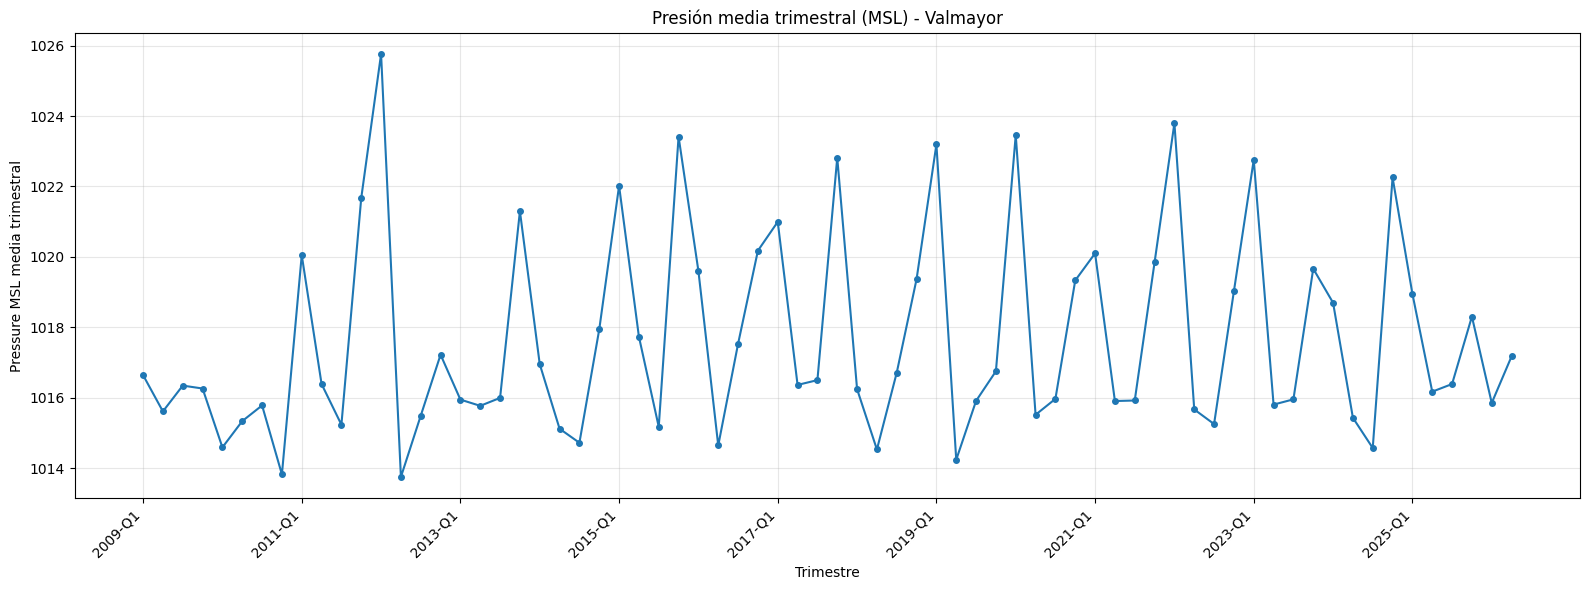

In [45]:
plt.figure(figsize=(16, 6))
x = range(len(df_pressure_quarter))

plt.plot(
    x,
    df_pressure_quarter["pressure_msl_mean_quarter"],
    marker="o",
    linewidth=1.5,
    markersize=4
)

tick_positions = list(range(0, len(df_pressure_quarter), 8))
tick_labels = df_pressure_quarter["year_quarter"].iloc[tick_positions]

plt.xticks(tick_positions, tick_labels, rotation=45, ha="right")
plt.title("Presión media trimestral (MSL) - Valmayor")
plt.xlabel("Trimestre")
plt.ylabel("Pressure MSL media trimestral")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Integración con el target trimestral

La tabla trimestral de presión se cruza con el dataset target definido en el notebook 07 para construir el bloque de presión del modelo final.

In [46]:
df_target = pd.read_parquet(TARGET_PATH)

print("Shape target:", df_target.shape)
df_target.head()

Shape target: (54, 11)


,year,year_quarter,n_videos,mean_activity_mentions,share_low,share_medium,share_high,share_certainty_high,captures_nonnull_mean,target_class,target_class_id
0,2009.0,2009-Q3,2,1.0,1.0,0.0,0.0,0.0,NaN,low,0
1,2009.0,2009-Q4,1,1.0,0.0,1.0,0.0,1.0,1.0,medium,1
2,2010.0,2010-Q1,1,1.0,1.0,0.0,0.0,0.0,NaN,low,0
3,2010.0,2010-Q2,2,1.0,0.0,1.0,0.0,0.5,1.0,medium,1
4,2011.0,2011-Q1,1,1.0,0.0,1.0,0.0,1.0,1.0,medium,1


In [47]:
df_model_pressure = (
    df_target
    .merge(
        df_pressure_quarter,
        on=["year", "year_quarter"],
        how="left"
    )
    .sort_values(["year", "year_quarter"])
    .reset_index(drop=True)
)

print("Shape tras merge:", df_model_pressure.shape)
df_model_pressure.head(12)

Shape tras merge: (54, 21)


,year,year_quarter,n_videos,mean_activity_mentions,share_low,share_medium,share_high,share_certainty_high,captures_nonnull_mean,target_class,...,quarter,pressure_msl_mean_quarter,pressure_msl_min_quarter,pressure_msl_max_quarter,pressure_msl_std_quarter,surface_pressure_mean_quarter,surface_pressure_min_quarter,surface_pressure_max_quarter,surface_pressure_std_quarter,n_obs_pressure_quarter
0,2009.0,2009-Q3,2,1.000000,1.000000,0.000000,0.0,0.000000,NaN,low,...,3,1016.347826,1009.3,1023.1,3.078657,925.219565,916.7,930.6,2.812657,92
1,2009.0,2009-Q4,1,1.000000,0.000000,1.000000,0.0,1.000000,1.0,medium,...,4,1016.265217,990.5,1031.3,7.303385,920.971739,897.5,933.8,7.262705,92
2,2010.0,2010-Q1,1,1.000000,1.000000,0.000000,0.0,0.000000,NaN,low,...,1,1014.594444,992.6,1026.5,7.834415,917.790000,897.3,929.5,7.288348,90
3,2010.0,2010-Q2,2,1.000000,0.000000,1.000000,0.0,0.500000,1.0,medium,...,2,1015.339560,1002.6,1025.2,5.070719,921.686813,909.5,931.1,5.109908,91
4,2011.0,2011-Q1,1,1.000000,0.000000,1.000000,0.0,1.000000,1.0,medium,...,1,1020.051111,1000.8,1034.0,7.409184,923.067778,904.6,935.4,6.919129,90
5,2011.0,2011-Q3,3,1.000000,0.000000,1.000000,0.0,0.666667,1.0,medium,...,3,1015.238043,1008.0,1024.3,3.562498,924.059783,918.0,931.7,3.047826,92
6,2011.0,2011-Q4,2,1.000000,0.500000,0.500000,0.0,0.500000,1.0,low,...,4,1021.672826,998.5,1035.2,7.538635,925.838043,904.5,935.5,6.467431,92
7,2012.0,2012-Q2,1,1.000000,1.000000,0.000000,0.0,0.000000,NaN,low,...,2,1013.753846,1005.0,1024.4,4.471348,920.707692,910.4,932.2,5.305034,91
8,2012.0,2012-Q3,2,1.000000,1.000000,0.000000,0.0,0.000000,NaN,low,...,3,1015.493478,1006.5,1024.8,3.364678,924.415217,913.4,934.1,3.371305,92
9,2012.0,2012-Q4,1,1.000000,0.000000,1.000000,0.0,0.000000,1.0,medium,...,4,1017.225000,1001.0,1033.0,6.849715,921.461957,906.3,934.1,5.900453,92


### Resumen descriptivo por clase

Se analiza de forma preliminar cómo se comportan las variables de presión según la clase objetivo trimestral.

In [48]:
summary_pressure_by_class = (
    df_model_pressure
    .groupby("target_class")
    .agg(
        n_trimestres=("year_quarter", "count"),
        n_videos_mean=("n_videos", "mean"),
        pressure_msl_mean_quarter=("pressure_msl_mean_quarter", "mean"),
        pressure_msl_min_quarter=("pressure_msl_min_quarter", "mean"),
        pressure_msl_max_quarter=("pressure_msl_max_quarter", "mean"),
        surface_pressure_mean_quarter=("surface_pressure_mean_quarter", "mean")
    )
    .round(3)
)

summary_pressure_by_class

,n_trimestres,n_videos_mean,pressure_msl_mean_quarter,pressure_msl_min_quarter,pressure_msl_max_quarter,surface_pressure_mean_quarter
target_class,,,,,,
high,4,2.250,1020.341,1002.450,1033.075,924.796
low,28,3.179,1016.566,1003.554,1026.904,923.395
medium,22,2.318,1018.041,1001.432,1029.895,923.607


## Guardado del dataset integrado con presión

Se persiste la versión del dataset que ya incorpora las variables trimestrales de presión, lista para combinarse con el resto de bloques del pipeline.

In [49]:
df_model_pressure.to_parquet(MODEL_PRESSURE_PATH, index=False)
df_model_pressure.to_csv(MODEL_PRESSURE_CSV_PATH, index=False, encoding="utf-8")

print("Guardado parquet:", MODEL_PRESSURE_PATH)
print("Guardado csv:", MODEL_PRESSURE_CSV_PATH)

Guardado parquet: /content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/valmayor_target_pressure_quarter.parquet
Guardado csv: /content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/valmayor_target_pressure_quarter.csv


## Conclusión

El notebook deja construida la tabla trimestral de presión atmosférica para Valmayor y la integra con el target de clasificación trimestral definido en el notebook 07. De este modo, la presión queda adaptada al nuevo enfoque temporal del TFG y lista para combinarse con la meteorología general, la hidrología y el resto de variables externas en el dataset final de modelado.